In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python scikit-learn matplotlib seaborn tqdm pandas numpy
!pip install pytorchvideo kagglehub albumentations
!apt-get install ffmpeg

import torch
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступен: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 21.6 MB/s eta 0:00:00
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=cbffe67b4b97533c1ecb477c3e14f1d03383c67804370e23b4413e5c0fa77dab
  Stored in directory: /root/.cache/pip/wheels/b3/49/dc/aab2dce83e38b59849db13a4f4ddd220e568e24b58332fb0f9
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=b481ea0b7d9035c63e11132328b99c09322600f3940ee748b626923e6a131b4d
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b2745

In [5]:
# Установка CLI
!pip install kaggle

# Загрузите ваш kaggle.json (из аккаунта Kaggle → Account → API → "Create New Token")
from google.colab import files
files.upload()  # Выберите файл kaggle.json

# Настройка
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Скачивание датасета
!kaggle datasets download -d toqaalaaawad/metal-surfaces-defects

# Распаковка
!unzip -q metal-surfaces-defects.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/toqaalaaawad/metal-surfaces-defects
License(s): unknown
 97% 912M/936M [00:11<00:00, 107MB/s] 
100% 936M/936M [00:11<00:00, 83.0MB/s]


In [11]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import numpy as np
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json
import time
import shutil

print("\nЗагрузка и обработка данных...")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root="Metal-surfaces-defects", transform=transform)
print(f"Загружено {len(full_dataset)} изображений в {len(full_dataset.classes)} классах.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")

resnet = models.resnet18(weights='IMAGENET1K_V1')
resnet.fc = nn.Identity()
resnet = resnet.to(device).eval()

embeddings = []
labels = []

dataloader_full = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=2)

with torch.no_grad():
    for images, targets in tqdm(dataloader_full, desc="Извлечение эмбеддингов"):
        images = images.to(device)
        emb = resnet(images)
        embeddings.append(emb.cpu().numpy())
        labels.append(targets.numpy())

embeddings = np.vstack(embeddings)  # (N, 512)
labels = np.hstack(labels)          # (N,)
print(f"Эмбеддинги: {embeddings.shape}, Метки: {labels.shape}")

X_train, X_val, y_train, y_val = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

train_tensor = torch.tensor(X_train, dtype=torch.float32)
val_tensor = torch.tensor(X_val, dtype=torch.float32)

train_loader = DataLoader(train_tensor, batch_size=64, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=64, shuffle=False)

# Сохраняем истинные метки для оценки
val_labels = y_val


Загрузка и обработка данных...
Загружено 3212 изображений в 12 классах.
Устройство: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]
Извлечение эмбеддингов: 100%|██████████| 101/101 [00:56<00:00,  1.77it/s]

Эмбеддинги: (3212, 512), Метки: (3212,)


In [12]:
class WorkingVaDE_Metal(nn.Module):
    def __init__(self, input_dim=512, z_dim=32, n_clusters=12):
        super().__init__()
        self.z_dim = z_dim
        self.n_clusters = n_clusters

        # Энкодер
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 500),
            nn.BatchNorm1d(500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.BatchNorm1d(500),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(500, z_dim)
        self.fc_logvar = nn.Linear(500, z_dim)
        self.fc_gamma = nn.Linear(500, n_clusters)

        # Декодер (восстанавливает эмбеддинги)
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, 500),
            nn.BatchNorm1d(500),
            nn.ReLU(),
            nn.Linear(500, input_dim)
        )

        # GMM prior
        centers = torch.randn(n_clusters, z_dim) * 3.0
        self.register_buffer('gmm_mu', centers)
        self.register_buffer('gmm_logvar', torch.ones(n_clusters, z_dim) * np.log(0.3))
        self.register_buffer('gmm_pi', torch.ones(n_clusters) / n_clusters)

    def encode(self, x, temperature=0.3):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = torch.clamp(self.fc_logvar(h), min=-4, max=3)
        gamma_logits = self.fc_gamma(h)
        gamma = F.softmax(gamma_logits / temperature, dim=-1)
        return mu, logvar, gamma

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, temperature=0.3):
        mu, logvar, gamma = self.encode(x, temperature)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, z, gamma, mu, logvar

    def compute_gmm_prob(self, z):
        B, D = z.shape
        K = self.n_clusters
        z_exp = z.unsqueeze(1)
        mu_exp = self.gmm_mu.unsqueeze(0)
        logvar_exp = self.gmm_logvar.unsqueeze(0)
        log_prob = -0.5 * (
            D * np.log(2 * np.pi) +
            logvar_exp.sum(-1) +
            ((z_exp - mu_exp) ** 2 / torch.exp(logvar_exp)).sum(-1)
        )
        log_prob = torch.log(self.gmm_pi + 1e-10) + log_prob
        return torch.logsumexp(log_prob, dim=1)

class WorkingTrainer:
    def __init__(self, model, device, eta=0.0):
        self.model = model
        self.device = device
        self.eta = eta

    def compute_loss(self, x, x_recon, z, gamma, mu, logvar):
        B = x.shape[0]
        recon_loss = F.mse_loss(x_recon, x, reduction='sum') / B
        log_q_z = -0.5 * torch.sum(
            logvar + (z - mu) ** 2 / torch.exp(logvar) + np.log(2 * np.pi),
            dim=1
        )
        log_p_z = self.model.compute_gmm_prob(z)
        kl_loss = torch.mean(log_q_z - log_p_z)
        expected_center = torch.matmul(gamma, self.model.gmm_mu)
        center_loss = F.mse_loss(z, expected_center, reduction='mean') * 5.0
        entropy = -torch.sum(gamma * torch.log(gamma + 1e-10), dim=1).mean()
        entropy_loss = -self.eta * entropy
        total_loss = recon_loss + 20.0 * kl_loss + center_loss + entropy_loss
        confidence = gamma.max(dim=1)[0].mean()
        return total_loss, {
            'total': total_loss.item(),
            'recon': recon_loss.item(),
            'kl': kl_loss.item(),
            'center': center_loss.item(),
            'entropy': entropy.item(),
            'entropy_loss': entropy_loss.item(),
            'confidence': confidence.item()
        }

    def train_epoch(self, train_loader, optimizer, epoch, temperature=0.3):
        self.model.train()
        epoch_loss = 0
        epoch_entropy = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1:3d}')
        for batch_idx, x in enumerate(pbar):
            x = x.to(self.device)
            optimizer.zero_grad()
            x_recon, z, gamma, mu, logvar = self.model(x, temperature)
            loss, loss_dict = self.compute_loss(x, x_recon, z, gamma, mu, logvar)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss_dict['total']
            epoch_entropy += loss_dict['entropy']
            if batch_idx % 20 == 0:
                pbar.set_postfix({
                    'loss': f"{loss_dict['total']:.1f}",
                    'H(γ)': f"{loss_dict['entropy']:.2f}",
                    'η': f"{self.eta:.2f}"
                })
        return {'loss': epoch_loss / len(train_loader), 'entropy': epoch_entropy / len(train_loader)}

    def evaluate(self, data_loader, true_labels, temperature=0.3):
        self.model.eval()
        all_gamma = []
        with torch.no_grad():
            for x in data_loader:
                x = x.to(self.device)
                _, _, gamma, _, _ = self.model(x, temperature)
                all_gamma.append(gamma.cpu().numpy())
        all_gamma = np.vstack(all_gamma)
        pred_labels = np.argmax(all_gamma, axis=1)
        nmi = normalized_mutual_info_score(true_labels, pred_labels)
        ari = adjusted_rand_score(true_labels, pred_labels)
        entropy = -np.sum(all_gamma * np.log(all_gamma + 1e-10), axis=1).mean()
        confidence = all_gamma.max(axis=1).mean()
        return {
            'nmi': nmi,
            'ari': ari,
            'entropy': entropy,
            'confidence': confidence,
            'gamma': all_gamma,
            'pred_labels': pred_labels
        }

def pretrain_autoencoder(model, train_loader, device, epochs=3):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    print("Предобучение автоэнкодера...")
    for epoch in range(epochs):
        total_loss = 0
        for x in tqdm(train_loader, desc=f"Предобучение {epoch+1}/{epochs}"):
            x = x.to(device)
            optimizer.zero_grad()
            mu, logvar, gamma = model.encode(x, temperature=1.0)
            z = model.reparameterize(mu, logvar)
            x_recon = model.decode(z)
            loss = F.mse_loss(x_recon, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: средний loss = {total_loss/len(train_loader):.4f}")
    return model

def run_experiment_for_eta(eta, device, num_epochs=15):
    print(f"\n{'='*60}")
    print(f"ЭКСПЕРИМЕНТ с η = {eta}")
    print(f"{'='*60}")
    start_time = time.time()

    model = WorkingVaDE_Metal(input_dim=512, z_dim=32, n_clusters=12).to(device)
    model = pretrain_autoencoder(model, train_loader, device, epochs=3)

    trainer = WorkingTrainer(model, device, eta=eta)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    history = {'train_loss': [], 'train_entropy': [], 'val_nmi': [], 'val_ari': [], 'val_entropy': []}

    for epoch in range(num_epochs):
        train_metrics = trainer.train_epoch(train_loader, optimizer, epoch, temperature=0.3)
        if epoch % 2 == 0 or epoch == num_epochs - 1:
            val_metrics = trainer.evaluate(val_loader, val_labels, temperature=0.3)
            history['train_loss'].append(train_metrics['loss'])
            history['train_entropy'].append(train_metrics['entropy'])
            history['val_nmi'].append(val_metrics['nmi'])
            history['val_ari'].append(val_metrics['ari'])
            history['val_entropy'].append(val_metrics['entropy'])
            if epoch % 5 == 0 or epoch < 3:
                print(f"Epoch {epoch+1:3d}: "
                      f"loss={train_metrics['loss']:.1f}, "
                      f"NMI={val_metrics['nmi']:.3f}, "
                      f"H(γ)={val_metrics['entropy']:.3f}")

    final_metrics = trainer.evaluate(val_loader, val_labels, temperature=0.3)
    elapsed_time = time.time() - start_time
    print(f"\nРезультаты для η={eta}:")
    print(f"  NMI: {final_metrics['nmi']:.4f}")
    print(f"  ARI: {final_metrics['ari']:.4f}")
    print(f"  H(γ): {final_metrics['entropy']:.4f}")

    return {
        'model': model,
        'history': history,
        'final_metrics': final_metrics,
        'elapsed_time': elapsed_time
    }

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    eta_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
    results = {}

    for eta in eta_values:
        results[eta] = run_experiment_for_eta(eta, device, num_epochs=15)

    # Сохранение результатов
    os.makedirs("metal_defects_results", exist_ok=True)
    results_dict = {}
    for eta in eta_values:
        results_dict[str(eta)] = {
            'nmi': float(results[eta]['final_metrics']['nmi']),
            'ari': float(results[eta]['final_metrics']['ari']),
            'entropy': float(results[eta]['final_metrics']['entropy']),
            'time': results[eta]['elapsed_time']
        }
    with open("metal_defects_results/results.json", "w") as f:
        json.dump(results_dict, f, indent=2)

    # Вывод таблицы
    print("\n" + "="*70)
    print("СВОДКА РЕЗУЛЬТАТОВ")
    print("="*70)
    print(f"{'η':<6} {'NMI':<10} {'ARI':<10} {'H(γ)':<10} {'Время (с)':<10}")
    print("-"*70)
    for eta in eta_values:
        m = results[eta]['final_metrics']
        t = results[eta]['elapsed_time']
        print(f"{eta:<6.2f} {m['nmi']:<10.4f} {m['ari']:<10.4f} {m['entropy']:<10.4f} {t:<10.1f}")
    print("="*70)
    print("\nРезультаты сохранены в папке: metal_defects_results/")

if __name__ == "__main__":
    main()


ЭКСПЕРИМЕНТ с η = 0.0
Предобучение автоэнкодера...


Предобучение 1/3: 100%|██████████| 41/41 [00:00<00:00, 46.97it/s]


Epoch 1: средний loss = 0.1851


Предобучение 2/3: 100%|██████████| 41/41 [00:00<00:00, 257.86it/s]


Epoch 2: средний loss = 0.0734


...

Epoch   3: loss=1437.0, NMI=0.291, H(γ)=0.960


Epoch  11: 100%|██████████| 41/41 [00:00<00:00, 133.18it/s, loss=534.7, H(γ)=0.65, η=1.00]


Epoch  11: loss=311.1, NMI=0.300, H(γ)=0.470


Epoch  15: 100%|██████████| 41/41 [00:00<00:00, 139.63it/s, loss=433.9, H(γ)=0.55, η=1.00]



Результаты для η=1.0:
  NMI: 0.3019
  ARI: 0.0854
  H(γ): 0.5361

СВОДКА РЕЗУЛЬТАТОВ
η      NMI        ARI        H(γ)       Время (с) 
----------------------------------------------------------------------
0.00   0.3943     0.2369     0.3224     6.2       
0.05   0.2472     0.1258     0.2310     5.7       
0.10   0.1272     0.0406     0.2094     5.0       
0.20   0.3815     0.1852     0.4653     5.1       
0.30   0.3621     0.2194     0.3294     5.6       
0.50   0.2696     0.1140     0.4770     5.2       
1.00   0.3019     0.0854     0.5361     5.8       

Результаты сохранены в папке: metal_defects_results/


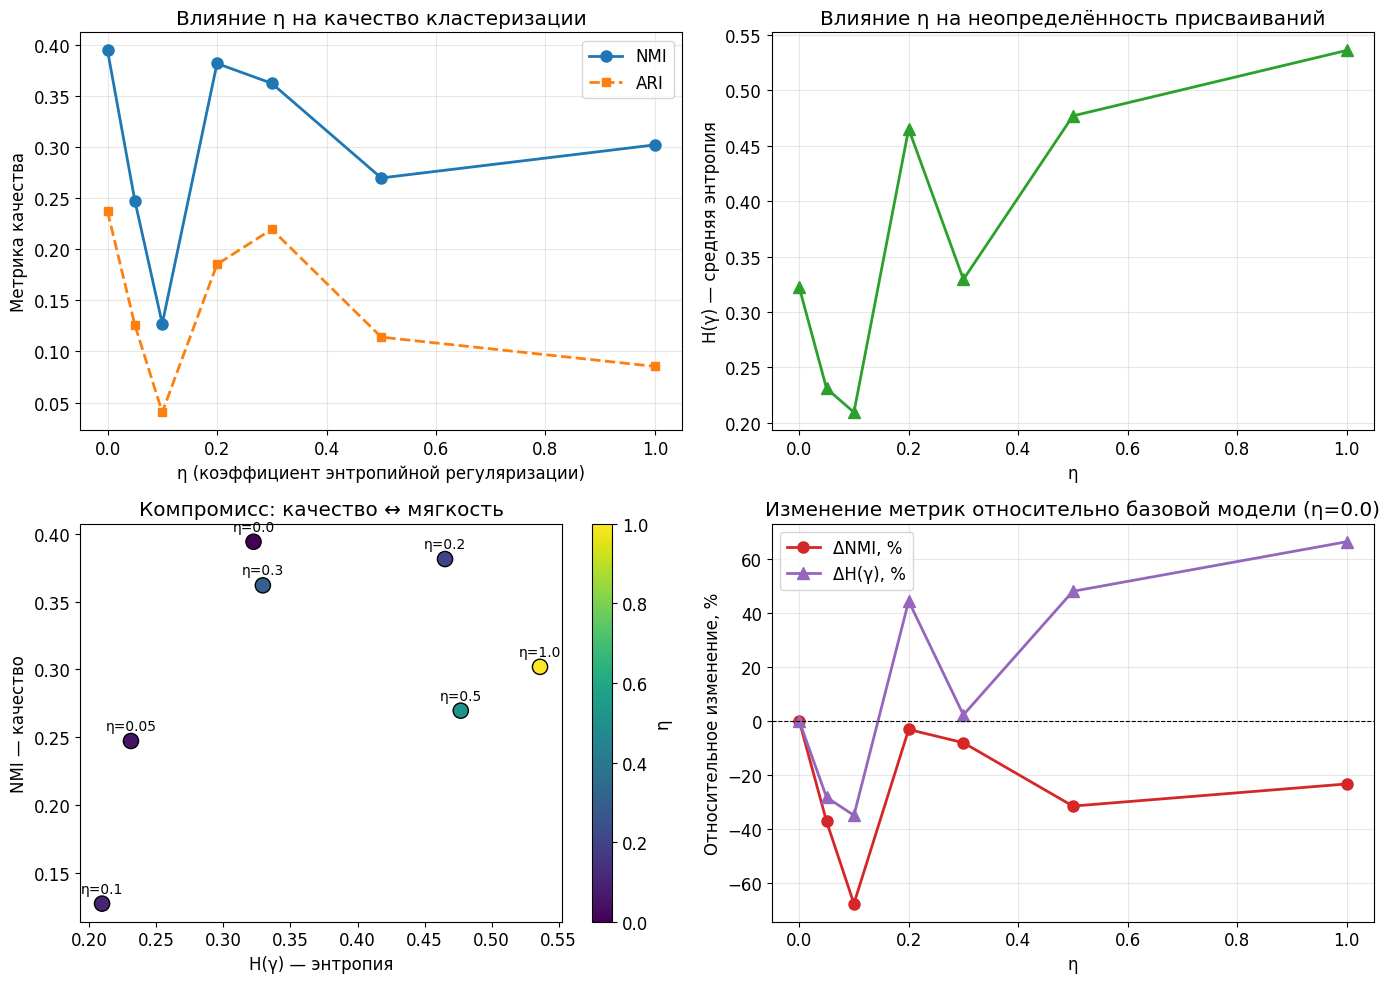

In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Загрузка результатов
with open('/content/metal_defects_results/results.json', 'r') as f:
    data = json.load(f)

# Извлекаем пары (ключ_как_строка, значение) и сортируем по числовому значению
items = []
for key_str, metrics in data.items():
    eta_val = float(key_str.strip())  # Убираем пробелы и конвертируем в float
    items.append((eta_val, key_str, metrics))

# Сортируем по числовому значению η
items.sort(key=lambda x: x[0])

# Теперь извлекаем данные в правильном порядке
etas = [item[0] for item in items]
nmi_vals = [item[2]["nmi"] for item in items]
ari_vals = [item[2]["ari"] for item in items]
entropy_vals = [item[2]["entropy"] for item in items]

# Далее — ваш код визуализации (без изменений)
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. NMI vs η
axes[0, 0].plot(etas, nmi_vals, 'o-', color='tab:blue', linewidth=2, markersize=8, label='NMI')
axes[0, 0].plot(etas, ari_vals, 's--', color='tab:orange', linewidth=2, markersize=6, label='ARI')
axes[0, 0].set_xlabel('η (коэффициент энтропийной регуляризации)')
axes[0, 0].set_ylabel('Метрика качества')
axes[0, 0].set_title('Влияние η на качество кластеризации')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Энтропия vs η
axes[0, 1].plot(etas, entropy_vals, '^-', color='tab:green', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('η')
axes[0, 1].set_ylabel('H(γ) — средняя энтропия')
axes[0, 1].set_title('Влияние η на неопределённость присваиваний')
axes[0, 1].grid(True, alpha=0.3)

# 3. Компромисс: NMI vs H(γ)
scatter = axes[1, 0].scatter(entropy_vals, nmi_vals, c=etas, cmap='viridis', s=120, edgecolor='k')
for i, eta in enumerate(etas):
    axes[1, 0].annotate(f'η={eta}', (entropy_vals[i], nmi_vals[i]),
                        textcoords="offset points", xytext=(0,8), ha='center', fontsize=10)
axes[1, 0].set_xlabel('H(γ) — энтропия')
axes[1, 0].set_ylabel('NMI — качество')
axes[1, 0].set_title('Компромисс: качество ↔ мягкость')
plt.colorbar(scatter, ax=axes[1, 0], label='η')

# 4. Относительное изменение (относительно η=0.0)
base_nmi = nmi_vals[0]
base_entropy = entropy_vals[0]
rel_nmi = [(nmi - base_nmi) / base_nmi * 100 for nmi in nmi_vals]
rel_entropy = [(ent - base_entropy) / base_entropy * 100 for ent in entropy_vals]

axes[1, 1].plot(etas, rel_nmi, 'o-', color='tab:red', linewidth=2, markersize=8, label='ΔNMI, %')
axes[1, 1].plot(etas, rel_entropy, '^-', color='tab:purple', linewidth=2, markersize=8, label='ΔH(γ), %')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_xlabel('η')
axes[1, 1].set_ylabel('Относительное изменение, %')
axes[1, 1].set_title('Изменение метрик относительно базовой модели (η=0.0)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metal_defects_analysis.png', dpi=150, bbox_inches='tight')
plt.show()